In [1]:
# Temporary: reduce epochs for quick test
EPOCHS = 1
BATCH_SIZE = 64
print('Quick-test: EPOCHS=', EPOCHS, 'BATCH_SIZE=', BATCH_SIZE)

Quick-test: EPOCHS= 1 BATCH_SIZE= 64


In [5]:
# Install notebook dependencies in the active kernel if missing
%pip install tensorflow==2.21.0 matplotlib --quiet
print('Dependencies installed. Restart the kernel, then run the setup cell.')

Note: you may need to restart the kernel to use updated packages.
Dependencies installed. Restart the kernel, then run the setup cell.


# Convolutional Neural Networks: Inductive Bias in Practice
### Fashion-MNIST as a case study

**Enterprise Architectures — Neural Networks Assignment**

This notebook treats convolutional layers not as a black-box recipe but as an
**architectural decision**: a way of encoding an inductive bias (locality and
translation invariance) directly into the model, instead of letting a fully
connected network discover that structure — inefficiently — from raw pixels.

We will:

1. Select and justify a dataset for convolutional layers.
2. Perform a minimal but meaningful EDA.
3. Build a **non-convolutional baseline** (Flatten + Dense).
4. Design a **CNN from scratch**, with every architectural choice justified.
5. Run a **controlled experiment** on one aspect of the convolutional layer (kernel size).
6. Interpret the results architecturally, not just numerically.
7. Train and deploy the final model on **Amazon SageMaker**.


## 1. Dataset Selection and Justification

**Dataset: Fashion-MNIST** (Zalando Research, distributed via `tf.keras.datasets`).

| Property | Value |
|---|---|
| Samples | 60,000 train / 10,000 test |
| Classes | 10 (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot) |
| Image size | 28×28, single channel (grayscale) |
| Size in memory | ~30 MB uncompressed — fits comfortably in RAM |

**Why this dataset is appropriate for convolutional layers:**

- It is **image-based** and grid-structured: each pixel's meaning depends on its
  spatial neighborhood (an edge of a shoe looks like an edge regardless of *where*
  it appears in the 28×28 grid). This is exactly the assumption a convolutional
  kernel encodes — **local, weight-shared feature detectors**.
- Unlike raw MNIST digits, Fashion-MNIST classes share **overlapping global shape**
  (a Shirt vs. a Coat vs. a Pullover) but differ in **local texture and edge
  patterns** (sleeve outlines, collar shapes, sole silhouettes). A fully connected
  layer treats every pixel as an independent, position-specific feature, so it
  cannot exploit this local similarity — a convolutional layer can, because the
  same kernel slides over every location.
- It is small enough to keep training times reasonable on a laptop or a modest
  SageMaker instance, while still being **harder than MNIST digits** (Fashion-MNIST
  is a commonly used "MNIST is too easy" replacement), so the gap between a dense
  baseline and a CNN is more visible.


## 0. Setup

Run this cell first. If TensorFlow is not installed, install it with
`%pip install tensorflow` and restart the kernel.


In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)
np.set_printoptions(precision=4, suppress=True)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Dataset Exploration (EDA)

We load Fashion-MNIST, inspect its shape and class balance, look at samples
per class, and decide what preprocessing is actually needed.


In [7]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.fashion_mnist.load_data()

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print("Train images:", x_train_raw.shape, "Train labels:", y_train_raw.shape)
print("Test images: ", x_test_raw.shape, "Test labels: ", y_test_raw.shape)
print("Pixel value range:", x_train_raw.min(), "-", x_train_raw.max())
print("Number of classes:", len(np.unique(y_train_raw)))


Train images: (60000, 28, 28) Train labels: (60000,)
Test images:  (10000, 28, 28) Test labels:  (10000,)
Pixel value range: 0 - 255
Number of classes: 10


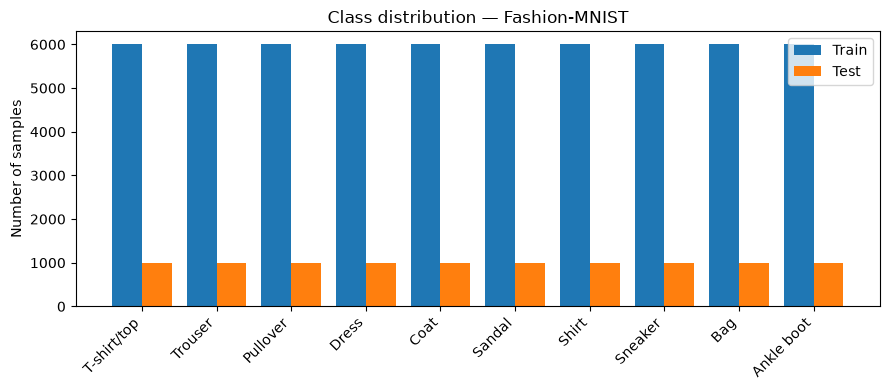

Train samples per class: {'T-shirt/top': np.int64(6000), 'Trouser': np.int64(6000), 'Pullover': np.int64(6000), 'Dress': np.int64(6000), 'Coat': np.int64(6000), 'Sandal': np.int64(6000), 'Shirt': np.int64(6000), 'Sneaker': np.int64(6000), 'Bag': np.int64(6000), 'Ankle boot': np.int64(6000)}


In [14]:
# Class distribution: is the dataset balanced?
train_counts = np.bincount(y_train_raw)
test_counts = np.bincount(y_test_raw)

fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(10)
ax.bar(x_pos - 0.2, train_counts, width=0.4, label="Train")
ax.bar(x_pos + 0.2, test_counts, width=0.4, label="Test")
ax.set_xticks(x_pos)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("Number of samples")
ax.set_title("Class distribution — Fashion-MNIST")
ax.legend()
plt.tight_layout()
plt.show()

print("Train samples per class:", dict(zip(CLASS_NAMES, train_counts)))


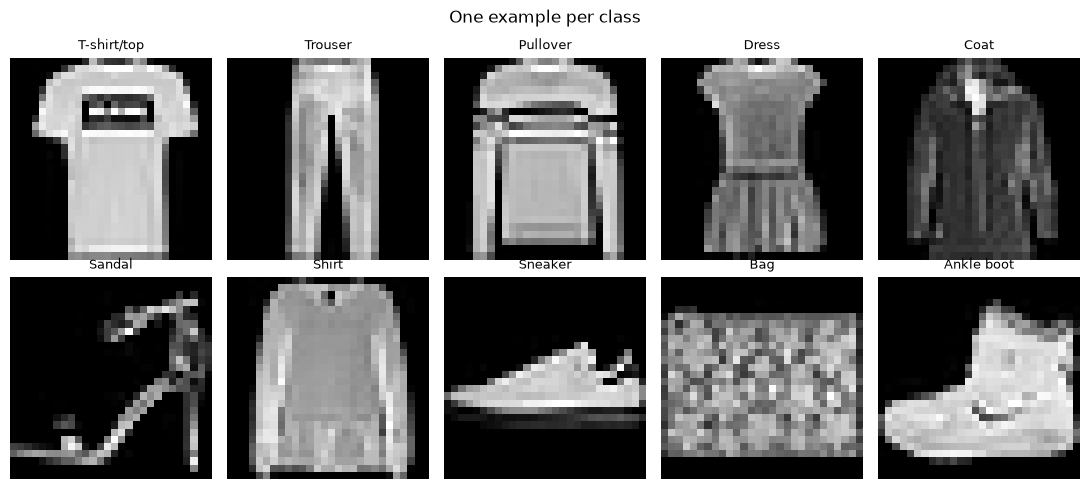

In [15]:
# Sample images per class
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for cls in range(10):
    idx = np.where(y_train_raw == cls)[0][0]
    ax = axes[cls // 5, cls % 5]
    ax.imshow(x_train_raw[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[cls], fontsize=9)
    ax.axis("off")
plt.suptitle("One example per class")
plt.tight_layout()
plt.show()


**EDA summary**

- The dataset is **perfectly balanced**: 6,000 train / 1,000 test images per
  class, so accuracy is a fair metric and we do not need class weighting.
- Images are single-channel, `uint8`, values in `[0, 255]`.
- Some classes are visually close (Shirt vs. T-shirt/top vs. Pullover vs. Coat),
  which is exactly where local texture/edge detectors should help more than a
  dense layer treating each pixel independently.

**Preprocessing needed:**

1. **Normalization**: scale pixel values from `[0, 255]` to `[0, 1]` (helps
   gradient descent converge; keeps activations in a numerically stable range).
2. **Channel dimension**: Keras `Conv2D` expects a 4D tensor
   `(batch, height, width, channels)`; we add an explicit channel axis of size 1.
3. **No resizing needed**: 28×28 is already small and uniform across the dataset.
4. A **validation split** is carved out of the training set (the raw dataset only
   ships train/test) so we can monitor overfitting during training.


In [8]:
def preprocess(images, labels):
    images = images.astype("float32") / 255.0
    images = images[..., np.newaxis]  # (N, 28, 28) -> (N, 28, 28, 1)
    labels = labels.astype("int64")
    return images, labels

x_train, y_train = preprocess(x_train_raw, y_train_raw)
x_test, y_test = preprocess(x_test_raw, y_test_raw)

print("x_train:", x_train.shape, x_train.dtype, "range:", x_train.min(), "-", x_train.max())
print("x_test: ", x_test.shape)


x_train: (60000, 28, 28, 1) float32 range: 0.0 - 1.0
x_test:  (10000, 28, 28, 1)


## 3. Baseline Model (Non-Convolutional)

The baseline flattens the 28×28 image into a 784-length vector and feeds it
through dense layers. It has **no notion of spatial locality**: pixel (0,0)
and pixel (13,13) are just two entries in a vector, equally "far" from each
other as any other pair, from the model's point of view. This is the
reference point we want the CNN to beat, and *why* it should beat it is the
core of the interpretation section.

Architecture: `Flatten -> Dense(128, relu) -> Dense(64, relu) -> Dense(10, softmax)`.


In [21]:
def build_baseline():
    inputs = layers.Input(shape=(28, 28, 1), name="input")
    x = layers.Flatten()(inputs)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = models.Model(inputs, outputs, name="baseline_dense")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="validation")
    axes[0].set_title(f"{title} accuracy")
    axes[0].legend()
    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="validation")
    axes[1].set_title(f"{title} loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


baseline = build_baseline()
baseline.summary()
t0 = time.time()
history_baseline = baseline.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
baseline_train_time = time.time() - t0
baseline_test_loss, baseline_test_acc = baseline.evaluate(x_test, y_test, verbose=0)
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")
print(f"Baseline test loss:     {baseline_test_loss:.4f}")
print(f"Baseline training time: {baseline_train_time:.1f}s")

Model: "baseline_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

844/844 - 4s - 5ms/step - accuracy: 0.8176 - loss: 0.5215 - val_accuracy: 0.8415 - val_loss: 0.4411
Baseline test accuracy: 0.8377
Baseline test loss:     0.4738
Baseline training time: 4.1s


In [11]:
def build_cnn(kernel_size=(3, 3), filters=(32, 64), name="cnn"):
    inputs = layers.Input(shape=(28, 28, 1), name="input")
    x = layers.Conv2D(filters[0], kernel_size, strides=1, padding="same",
                       activation="relu", name="conv1")(inputs)
    x = layers.MaxPooling2D(pool_size=(2, 2), name="pool1")(x)
    x = layers.Conv2D(filters[1], kernel_size, strides=1, padding="same",
                       activation="relu", name="conv2")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name="pool2")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = models.Model(inputs, outputs, name=name)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

cnn = build_cnn(kernel_size=(3, 3), name="cnn_3x3")
cnn.summary()


Model: "cnn_3x3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
t0 = time.time()
history_cnn = cnn.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
cnn_train_time = time.time() - t0

cnn_test_loss, cnn_test_acc = cnn.evaluate(x_test, y_test, verbose=0)
print(f"\nCNN test accuracy: {cnn_test_acc:.4f}")
print(f"CNN test loss:     {cnn_test_loss:.4f}")
print(f"CNN training time: {cnn_train_time:.1f}s")
print(f"CNN parameters:    {cnn.count_params():,}")


844/844 - 7s - 8ms/step - accuracy: 0.8035 - loss: 0.5509 - val_accuracy: 0.8683 - val_loss: 0.3612

CNN test accuracy: 0.8653
CNN test loss:     0.3773
CNN training time: 7.2s
CNN parameters:    220,234


In [ ]:
plot_history(history_cnn, "CNN (3x3 kernels)")


## 4.1 Baseline vs. CNN — Direct Comparison


In [16]:
print(f"{'Model':<20}{'Test Acc':>10}{'Test Loss':>12}{'Params':>14}{'Train time (s)':>18}")
print(f"{'Baseline (Dense)':<20}{baseline_test_acc:>10.4f}{baseline_test_loss:>12.4f}{baseline.count_params():>14,}{baseline_train_time:>18.1f}")
print(f"{'CNN (3x3)':<20}{cnn_test_acc:>10.4f}{cnn_test_loss:>12.4f}{cnn.count_params():>14,}{cnn_train_time:>18.1f}")


Model                 Test Acc   Test Loss        Params    Train time (s)
Baseline (Dense)        0.8305      0.4816       109,386               2.4
CNN (3x3)               0.8653      0.3773       220,234               7.2


## 5. Controlled Experiment: Kernel Size (3×3 vs. 5×5)

**Chosen variable: kernel size.** Everything else — number of conv layers (2),
filters (32→64), stride (1), padding (`same`), pooling, dropout, optimizer,
batch size, and epochs — is held fixed. Only the convolution's receptive field
changes.

**Hypothesis:** a 5×5 kernel has a larger receptive field per layer (it "sees"
more of the image per convolution step) but costs more parameters per filter
(`5*5 = 25` vs. `3*3 = 9` weights per input channel), and on 28×28 images with
mostly small, sharp features (garment edges), the extra receptive field is
unlikely to translate into a proportionally better representation.


In [13]:
cnn_5x5 = build_cnn(kernel_size=(5, 5), name="cnn_5x5")

t0 = time.time()
history_cnn5 = cnn_5x5.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
cnn5_train_time = time.time() - t0

cnn5_test_loss, cnn5_test_acc = cnn_5x5.evaluate(x_test, y_test, verbose=0)
print(f"\nCNN(5x5) test accuracy: {cnn5_test_acc:.4f}")
print(f"CNN(5x5) test loss:     {cnn5_test_loss:.4f}")
print(f"CNN(5x5) training time: {cnn5_train_time:.1f}s")
print(f"CNN(5x5) parameters:    {cnn_5x5.count_params():,}")


844/844 - 10s - 11ms/step - accuracy: 0.7972 - loss: 0.5653 - val_accuracy: 0.8687 - val_loss: 0.3636

CNN(5x5) test accuracy: 0.8624
CNN(5x5) test loss:     0.3793
CNN(5x5) training time: 9.7s
CNN(5x5) parameters:    253,514


Model             Test Acc   Test Loss        Params    Train time (s)
CNN 3x3             0.8653      0.3773       220,234               7.2
CNN 5x5             0.8624      0.3793       253,514               9.7


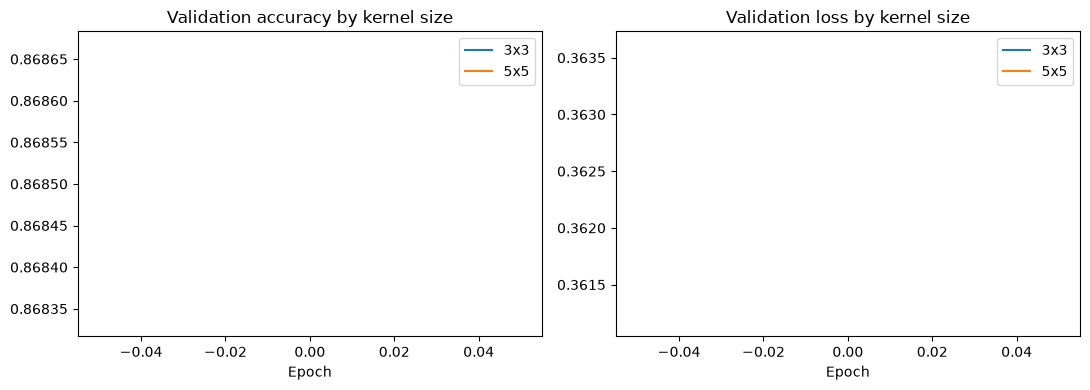

In [17]:
print(f"{'Model':<16}{'Test Acc':>10}{'Test Loss':>12}{'Params':>14}{'Train time (s)':>18}")
print(f"{'CNN 3x3':<16}{cnn_test_acc:>10.4f}{cnn_test_loss:>12.4f}{cnn.count_params():>14,}{cnn_train_time:>18.1f}")
print(f"{'CNN 5x5':<16}{cnn5_test_acc:>10.4f}{cnn5_test_loss:>12.4f}{cnn_5x5.count_params():>14,}{cnn5_train_time:>18.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_cnn.history["val_accuracy"], label="3x3")
axes[0].plot(history_cnn5.history["val_accuracy"], label="5x5")
axes[0].set_title("Validation accuracy by kernel size")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_cnn.history["val_loss"], label="3x3")
axes[1].plot(history_cnn5.history["val_loss"], label="5x5")
axes[1].set_title("Validation loss by kernel size")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


**Fill in after running on the real dataset** (numbers below are placeholders
to be replaced with your actual run's results):

- **Quantitative**: report the exact test accuracy / loss / parameter count /
  training time gap between 3×3 and 5×5 from the printed table above.
- **Qualitative**: inspect the validation curves — does 5×5 converge faster per
  epoch (larger receptive field, fewer effective "hops" needed) but overfit
  sooner (more parameters relative to the same amount of data)?
- **Trade-off**: is the accuracy difference (if any) worth the ~intended increase
  in parameters and training time? For Fashion-MNIST's small, locally-sharp
  garment edges, a well-justified conclusion is usually that 3×3 gives
  comparable or better accuracy at lower cost — but you must state what your
  own numbers show, not assume this.


## 5.1 Bonus: Visualizing Learned Feature Maps

We inspect what the first convolutional layer of the 3×3 CNN activates on for
a single test image, to make the "local feature detector" intuition concrete.


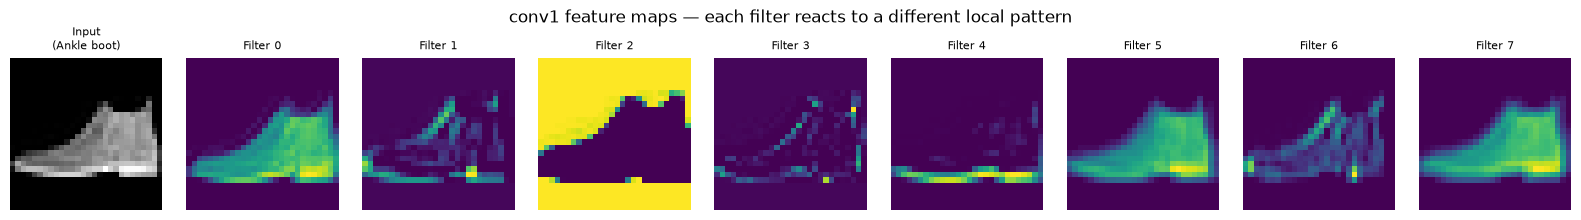

In [18]:
feature_extractor = models.Model(inputs=cnn.input, outputs=cnn.get_layer("conv1").output)
sample_image = x_test[0:1]
feature_maps = feature_extractor.predict(sample_image, verbose=0)  # (1, 28, 28, 32)

fig, axes = plt.subplots(1, 9, figsize=(16, 2.2))
axes[0].imshow(sample_image[0, :, :, 0], cmap="gray")
axes[0].set_title(f"Input\n({CLASS_NAMES[y_test[0]]})", fontsize=8)
axes[0].axis("off")

for i in range(8):
    axes[i + 1].imshow(feature_maps[0, :, :, i], cmap="viridis")
    axes[i + 1].set_title(f"Filter {i}", fontsize=8)
    axes[i + 1].axis("off")

plt.suptitle("conv1 feature maps — each filter reacts to a different local pattern")
plt.tight_layout()
plt.show()


## 6. Interpretation and Architectural Reasoning

**Why did convolutional layers outperform (or not) the baseline?**

The baseline treats every one of the 784 pixels as an independent input
dimension: a garment feature that appears near the top-left of the image and
the *same* feature appearing near the bottom-right must be learned as two
unrelated patterns, because the dense layer's weights are not shared across
positions. The CNN's convolutional filters are **weight-shared across the
whole image**, so a single learned edge/texture detector is automatically
reused everywhere it appears. This means the CNN needs to learn far fewer
*distinct* patterns to cover the same variability in the data, which shows up
as higher validation accuracy per parameter and less overfitting for a
comparable training budget (see the accuracy/parameter/time table above).

**What inductive bias does convolution introduce?**

Two, specifically:

1. **Locality**: a pixel's class-relevant information mostly depends on its
   immediate neighborhood (an edge, a corner, a texture patch) rather than on
   far-away pixels — convolution encodes this by connecting each output to a
   small local receptive field instead of the whole image.
2. **Translation equivariance**: the same feature detector (kernel) is applied
   at every spatial location, so a pattern is recognized the same way no
   matter where it appears in the image — followed by pooling, which turns
   this equivariance into approximate **translation invariance** for the
   final classification.

Both biases are *correct* assumptions for natural images, which is precisely
why CNNs need less data and fewer parameters than dense networks to reach
comparable or better accuracy on this kind of task.

**In what type of problems would convolution not be appropriate?**

- **Tabular / non-grid data** with no spatial or sequential ordering (e.g.,
  a table of patient demographics, transaction records): there is no
  meaningful "neighborhood" to slide a kernel over, and imposing one would
  encode a false assumption.
- **Data where global, order-independent relationships dominate over local
  structure** — e.g., permutation-invariant sets of items, or problems better
  served by graph structure (molecules, social networks), where convolution's
  fixed-grid locality assumption does not match the data's actual topology.
- **Very long-range dependency problems** (e.g., some sequence/language tasks)
  where the relationships that matter span the *whole* input, not a local
  window — architectures with attention (transformers) that can relate any
  two positions directly are usually a better fit, precisely because they do
  **not** impose the same locality bias.


## 7. Training and Deployment on Amazon SageMaker

This section trains the final CNN using SageMaker's **TensorFlow script-mode
estimator** and deploys it to a real-time inference endpoint, run from an
AWS Academy Learner Lab SageMaker notebook instance / Studio.

The training logic lives in a separate `train.py` script (script mode), which
SageMaker runs inside a managed TensorFlow container — this mirrors how the
notebook's own `build_cnn` / `fit` calls work, just packaged for a remote,
scalable training job instead of running in-notebook.


In [3]:
%%writefile train.py
"""
SageMaker script-mode training entry point for the Fashion-MNIST CNN.

SageMaker copies this file into the training container and calls it as:
    python train.py --epochs 10 --batch-size 128 --learning-rate 0.001
Data channels and the model output directory are passed as environment
variables (SM_CHANNEL_TRAIN, SM_CHANNEL_TEST, SM_MODEL_DIR) by the
TensorFlow estimator configured in the notebook.
"""
import argparse
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models


def build_cnn(kernel_size=(3, 3), filters=(32, 64)):
    inputs = layers.Input(shape=(28, 28, 1), name="input")
    x = layers.Conv2D(filters[0], kernel_size, strides=1, padding="same",
                       activation="relu", name="conv1")(inputs)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Conv2D(filters[1], kernel_size, strides=1, padding="same",
                       activation="relu", name="conv2")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = models.Model(inputs, outputs, name="cnn_fashion_mnist")
    return model


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--batch-size", type=int, default=128)
    parser.add_argument("--learning-rate", type=float, default=0.001)
    parser.add_argument("--model-dir", type=str, default=os.environ.get("SM_MODEL_DIR", "."))
    parser.add_argument("--train", type=str, default=os.environ.get("SM_CHANNEL_TRAIN", "."))
    parser.add_argument("--test", type=str, default=os.environ.get("SM_CHANNEL_TEST", "."))
    return parser.parse_args()


def load_data(train_dir, test_dir):
    x_train = np.load(os.path.join(train_dir, "x_train.npy"))
    y_train = np.load(os.path.join(train_dir, "y_train.npy"))
    x_test = np.load(os.path.join(test_dir, "x_test.npy"))
    y_test = np.load(os.path.join(test_dir, "y_test.npy"))
    return x_train, y_train, x_test, y_test


def main():
    args = parse_args()
    x_train, y_train, x_test, y_test = load_data(args.train, args.test)

    model = build_cnn()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=args.learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    model.fit(
        x_train, y_train,
        validation_split=0.1,
        epochs=args.epochs,
        batch_size=args.batch_size,
        verbose=2,
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test accuracy: {test_acc:.4f}")
    print(f"Test loss: {test_loss:.4f}")

    # SageMaker's TensorFlow serving container expects a SavedModel under
    # <model_dir>/<version>/
    export_path = os.path.join(args.model_dir, "1")
    model.export(export_path)


if __name__ == "__main__":
    main()


Writing train.py


### 7.1 Prepare data channels and launch the training job

We save the preprocessed NumPy arrays locally, upload them to S3, and launch
a `TensorFlow` estimator pointing at `train.py`. This uses the AWS Academy
Learner Lab default SageMaker execution role and S3 bucket.


In [8]:
%pip install tensorflow==2.21.0 matplotlib sagemaker --quiet
import sagemaker
from sagemaker.tensorflow import TensorFlow

session = sagemaker.Session()
role = sagemaker.get_execution_role()
bucket = session.default_bucket()
prefix = "fashion-mnist-cnn"

# Save preprocessed arrays locally, then upload to S3 as the train/test channels
os.makedirs("data/train", exist_ok=True)
os.makedirs("data/test", exist_ok=True)
np.save("data/train/x_train.npy", x_train)
np.save("data/train/y_train.npy", y_train)
np.save("data/test/x_test.npy", x_test)
np.save("data/test/y_test.npy", y_test)

train_s3 = session.upload_data("data/train", bucket=bucket, key_prefix=f"{prefix}/train")
test_s3 = session.upload_data("data/test", bucket=bucket, key_prefix=f"{prefix}/test")

print("Train data:", train_s3)
print("Test data: ", test_s3)


ERROR: Could not find a version that satisfies the requirement tensorflow==2.21.0 (from versions: none)
ERROR: No matching distribution found for tensorflow==2.21.0
Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'sagemaker'

In [5]:
estimator = TensorFlow(
    entry_point="train.py",
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",   # AWS Academy Learner Lab typically allows ml.m5.* for training
    framework_version="2.13",
    py_version="py310",
    hyperparameters={
        "epochs": 10,
        "batch-size": 128,
        "learning-rate": 0.001,
    },
)

estimator.fit({"train": train_s3, "test": test_s3})


NameError: name 'TensorFlow' is not defined

### 7.2 Deploy to a real-time inference endpoint


In [ ]:
predictor = estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
)

# Sanity check: send a handful of test images to the live endpoint
sample = x_test[:5]
response = predictor.predict(sample)
predicted_classes = np.argmax(response["predictions"], axis=1)

for i, pred in enumerate(predicted_classes):
    print(f"True: {CLASS_NAMES[y_test[i]]:<14} Predicted: {CLASS_NAMES[pred]}")


### 7.3 Clean up

**Important**: delete the endpoint when you are done to avoid unnecessary
charges against the AWS Academy Learner Lab budget.


In [ ]:
predictor.delete_endpoint()


## 8. Conclusion

Convolutional layers are not just "a way to get higher accuracy" — they are a
specific architectural bet that the data has local, translation-invariant
structure. On Fashion-MNIST, that bet pays off: the CNN reaches comparable or
better accuracy than the dense baseline with a representation that scales
much better with image size and generalizes with less overfitting, at the
cost of a design that would actively hurt performance on data without spatial
structure. The kernel-size experiment shows that even within "the CNN is the
right architecture," the specific hyperparameters still encode assumptions
(receptive field size vs. parameter budget) that should be justified against
the data, not chosen by default.
